In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

In [4]:
data = pd.read_csv(
    "../data/features.csv",
    index_col=0,
    parse_dates=True
)

data.head()

,Close,Log_Return,Return,SMA20,SMA50,SMA100,SMA200,EMA20,Momentum10,Momentum20,...,Lag2,Lag5,Lag10,Price_SMA20,Price_SMA50,UpperBand,LowerBand,RSI,MACD,MACD_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,24.883137,-0.007358,-0.007331,25.046606,25.176153,26.631793,27.035149,25.013353,0.147905,-0.540051,...,-0.014235,0.023645,0.007274,0.993473,0.988361,25.889497,24.203715,45.695046,-0.136604,-0.159600
2015-10-19,25.037760,0.006195,0.006214,25.007615,25.159167,26.588194,27.039375,25.015677,0.212889,-0.779835,...,0.014861,-0.004649,0.003617,1.001205,0.995174,25.768494,24.246735,59.838000,-0.118958,-0.151471
2015-10-20,25.494896,0.018093,0.018258,25.011760,25.132500,26.552512,27.049294,25.061317,0.551258,0.082909,...,-0.007358,0.001701,0.004773,1.019316,1.014419,25.782752,24.240768,62.073745,-0.067310,-0.134639
2015-10-21,25.492657,-0.000088,-0.000088,25.005486,25.133710,26.516227,27.059191,25.102397,0.667786,-0.125488,...,0.006195,-0.014235,-0.004773,1.019483,1.014281,25.757509,24.253462,65.300136,-0.026256,-0.112962
2015-10-22,25.882586,0.015180,0.015296,25.011088,25.134875,26.485136,27.069389,25.176701,1.344553,0.112059,...,0.018093,0.014861,-0.011622,1.034844,1.029748,25.788357,24.233819,67.534311,0.037312,-0.082907


In [5]:
features = [
    "Log_Return",
    "Volatility20",
    "Momentum10",
    "RSI",
    "MACD",
    "SMA20",
    "SMA50"
]


dataset = data[features].dropna()

dataset.head()

,Log_Return,Volatility20,Momentum10,RSI,MACD,SMA20,SMA50
Date,,,,,,,
2015-10-16,-0.007358,0.013340,0.147905,45.695046,-0.136604,25.046606,25.176153
2015-10-19,0.006195,0.012893,0.212889,59.838000,-0.118958,25.007615,25.159167
2015-10-20,0.018093,0.013142,0.551258,62.073745,-0.067310,25.011760,25.132500
2015-10-21,-0.000088,0.013009,0.667786,65.300136,-0.026256,25.005486,25.133710
2015-10-22,0.015180,0.013399,1.344553,67.534311,0.037312,25.011088,25.134875


In [6]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    dataset
)

In [7]:
def create_sequences(
    data,
    window=60
):

    X = []
    y = []

    for i in range(
        window,
        len(data)
    ):

        X.append(
            data[i-window:i]
        )

        y.append(
            data[i,0]
        )

    return np.array(X), np.array(y)

In [8]:
X, y = create_sequences(
    scaled_data,
    window=60
)


print(X.shape)
print(y.shape)

(2642, 60, 7)
(2642,)


In [9]:
split = int(
    len(X)*0.8
)


X_train = X[:split]

X_test = X[split:]


y_train = y[:split]

y_test = y[split:]

In [10]:
model = Sequential()


model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)


model.add(
    Dropout(0.2)
)


model.add(
    LSTM(
        32
    )
)


model.add(
    Dropout(0.2)
)


model.add(
    Dense(1)
)


model.compile(
    optimizer="adam",
    loss="mse"
)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)


history = model.fit(

    X_train,
    y_train,

    epochs=100,

    batch_size=32,

    validation_split=0.1,

    callbacks=[
        early_stop
    ],

    verbose=1
)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.0358 - val_loss: 0.0032
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0081 - val_loss: 0.0027
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0074 - val_loss: 0.0025
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0072 - val_loss: 0.0025
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0078 - val_loss: 0.0024
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0068 - val_loss: 0.0029
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0070 - val_loss: 0.0026
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0068 - val_loss: 0.0029
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0067 - val_loss: 0.0023
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0064 - val_loss: 0.0023
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0064 - val_loss: 0.0023
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step

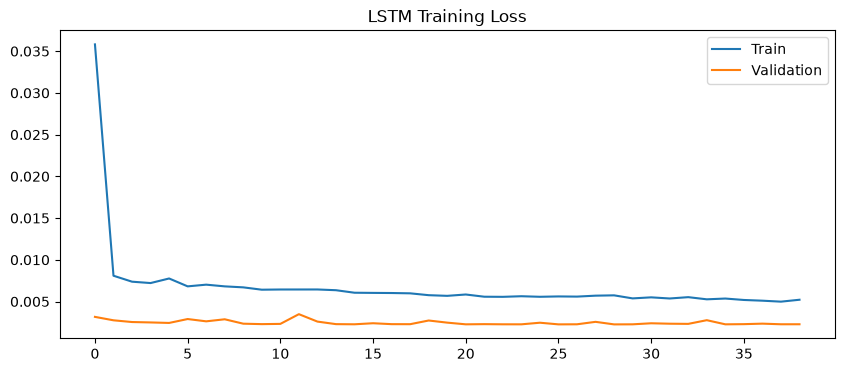

In [12]:
plt.figure(figsize=(10,4))


plt.plot(
    history.history["loss"],
    label="Train"
)


plt.plot(
    history.history["val_loss"],
    label="Validation"
)


plt.legend()

plt.title(
    "LSTM Training Loss"
)

plt.show()

In [15]:
prediction = prediction.flatten()

In [16]:
dummy_pred = np.zeros(
    (
        len(prediction),
        dataset.shape[1]
    )
)

dummy_actual = np.zeros(
    (
        len(y_test),
        dataset.shape[1]
    )
)


dummy_pred[:,0] = prediction

dummy_actual[:,0] = y_test


prediction_original = scaler.inverse_transform(
    dummy_pred
)[:,0]


actual_original = scaler.inverse_transform(
    dummy_actual
)[:,0]

In [17]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        prediction
    )
)


mae = mean_absolute_error(
    y_test,
    prediction
)


direction_accuracy = (
    np.sign(y_test)
    ==
    np.sign(
        prediction.flatten()
    )
).mean()


print(
    "RMSE:",
    rmse
)

print(
    "MAE:",
    mae
)

print(
    "Direction Accuracy:",
    direction_accuracy
)

RMSE: 0.06445302052700035
MAE: 0.04342651133109036
Direction Accuracy: 1.0


In [18]:
print(prediction[:10])
print(y_test[:10])

[0.48897055 0.4887324  0.48865205 0.4885491  0.4888242  0.4889373
 0.4888746  0.48895895 0.48935196 0.48957795]
[0.46583799 0.53517663 0.42227583 0.74142115 0.59176019 0.51077839
 0.46198472 0.56073544 0.45184175 0.4136626 ]


In [20]:
import pandas as pd

print(
    pd.Series(
        np.sign(y_test)
    ).value_counts()
)

1.0    529
Name: count, dtype: int64


In [21]:
direction_check = pd.DataFrame({

    "Actual":
    actual_original,

    "Prediction":
    prediction_original

})


direction_check["Actual_Direction"] = (
    np.sign(
        direction_check["Actual"]
    )
)


direction_check["Prediction_Direction"] = (
    np.sign(
        direction_check["Prediction"]
    )
)


direction_check.head(20)

,Actual,Prediction,Actual_Direction,Prediction_Direction
0,-0.007122,-0.000637,-1.0,-1.0
1,0.012316,-0.000704,1.0,-1.0
2,-0.019333,-0.000726,-1.0,-1.0
3,0.070131,-0.000755,1.0,-1.0
4,0.028177,-0.000678,1.0,-1.0
5,0.005476,-0.000646,1.0,-1.0
6,-0.008202,-0.000664,-1.0,-1.0
7,0.019480,-0.000640,1.0,-1.0
8,-0.011045,-0.000530,-1.0,-1.0
9,-0.021748,-0.000467,-1.0,-1.0


In [22]:
baseline_lstm_results = {
    "RMSE": 0.064453,
    "MAE": 0.043427,
    "Direction Accuracy": None,
    "Model": "LSTM Regression"
}